In [1]:
import nibabel as nib
import statistics as stats
import csv
import numpy as np
import nilearn.plotting
from nilearn.datasets import fetch_surf_fsaverage
import matplotlib.pyplot as plt



Matplotlib is building the font cache; this may take a moment.


In [10]:
# Loads atlas
atlas_dir = '/fs03/kg98/gchan/Atlases/Tian/Schaefer_Tian/reordered/'
# Schaefer 100 and Tian 32 atlases
atlas_img = nib.load(atlas_dir + 'Schaefer2018_100Parcels_7Networks_order_Tian_Subcortex_S2_MNI152NLin6Asym_1.5mm_reordered.nii.gz')
# disp = nilearn.plotting.plot_stat_map(atlas_img, cmap='coolwarm')

atlas_surf = np.genfromtxt('/fs03/kg98/jamesp/atlases/Human_cortical/fsaverage5_10k_Schaefer100-lh.txt', delimiter=',')


fsaverage = fetch_surf_fsaverage("fsaverage5")

In [70]:
import pandas as pd

gene_df = pd.read_csv('../enrichment/data/251114_gene_pair_pvalues.csv')
gene_df = gene_df[(gene_df['p_spatial_fdr']<0.05) & (gene_df['p_rewired_fdr']<0.05) & (gene_df['p_gene_fdr']<0.05)]

seed_counts = np.array([gene_df['seed'].value_counts().get(i, 0) for i in range(1, 67)]) + 1  # so that no cortical verts have a value of 0
# seed_counts = np.genfromtxt('./filtered_df_seed_counts.csv', delimiter=',')
# seed_counts = seed_counts[:, 1]

In [72]:
seed_counts.tofile('/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/enrichment/data/seed_counts.csv', sep=',')

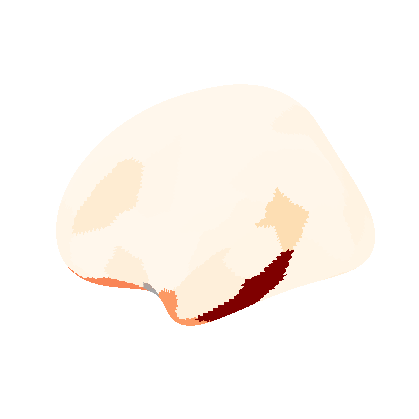

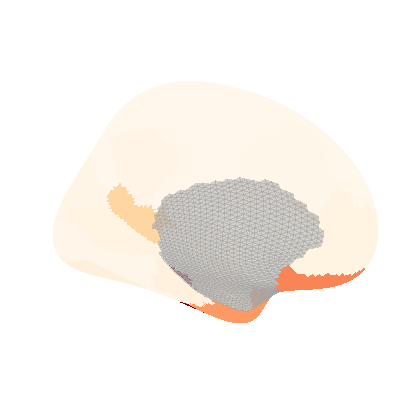

In [71]:
epicentre_surf = seed_counts[atlas_surf.astype(int)-1]
epicentre_surf = epicentre_surf.astype(float)
epicentre_surf[atlas_surf == 0] = np.nan
# fig = plt.figure(figsize=(15, 12))
disp = nilearn.plotting.plot_surf_roi(fsaverage.infl_left, roi_map=epicentre_surf, hemi='left', view='lateral', cmap='OrRd')
# disp.gca().set_facecolor((0.8, 0.8, 0.8))
disp = nilearn.plotting.plot_surf_roi(fsaverage.infl_left, roi_map=epicentre_surf, hemi='left', view='medial',  cmap='OrRd')
# disp.gca().set_facecolor((0.8, 0.8, 0.8))

In [53]:
print(disp)

Figure(400x400)


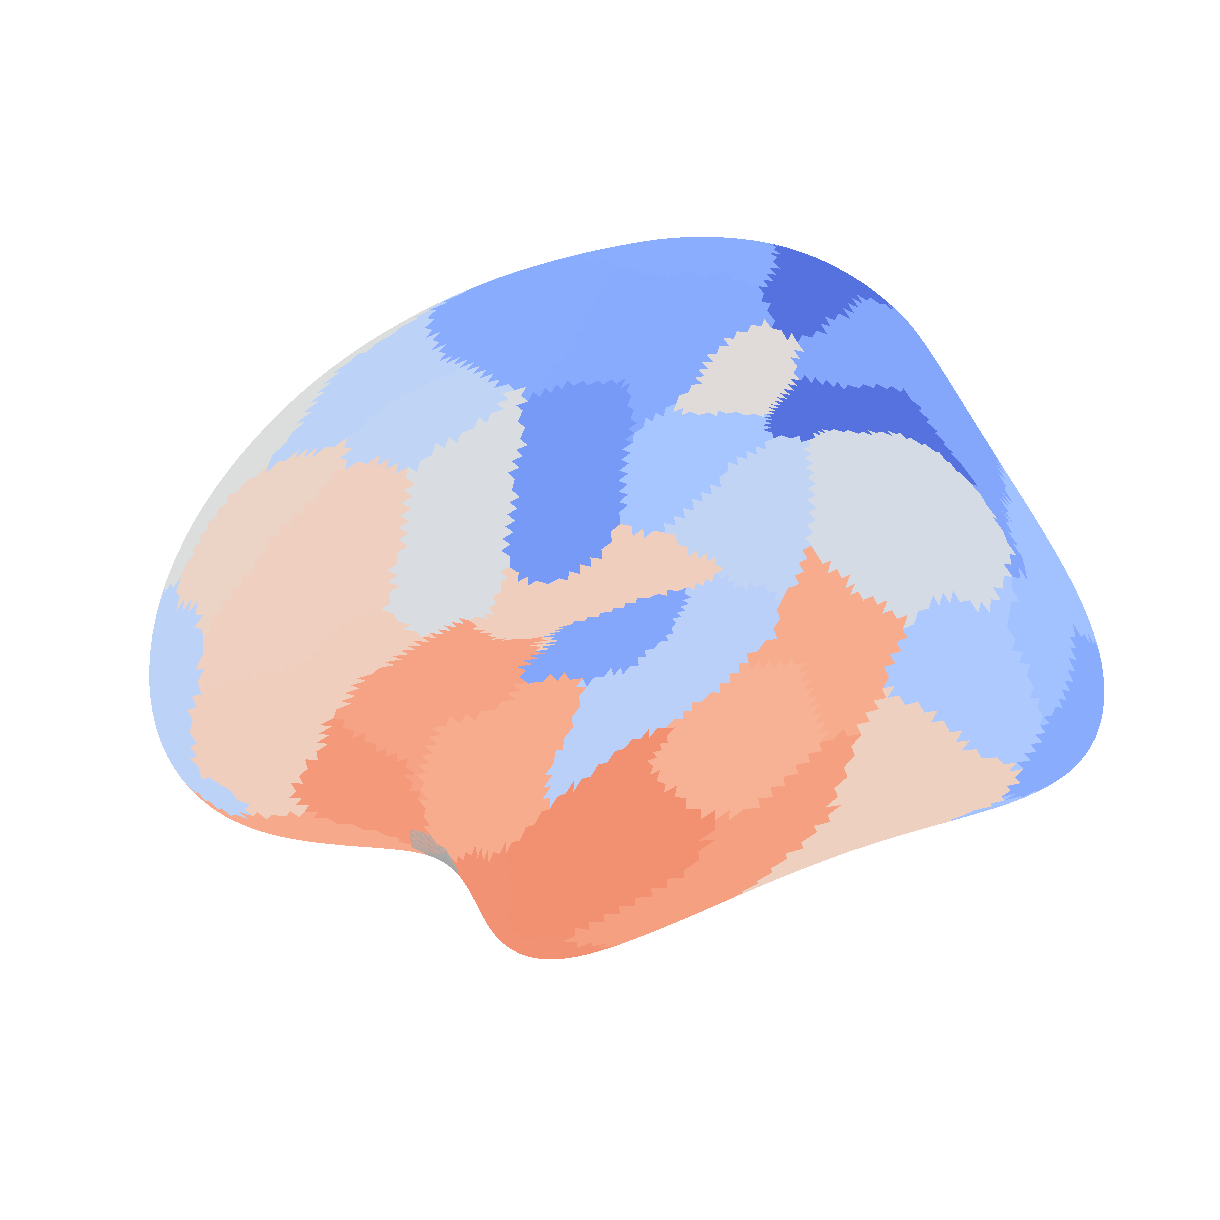

In [5]:
sim_atrophy = np.genfromtxt('/fs03/kg98/gchan/SIR_SCZ/SIR_simulator/results/rnf144a_tcap_seed38.csv', delimiter=',')
sim_atrophy = (sim_atrophy - np.mean(sim_atrophy)) / np.std(sim_atrophy)

sim_atrophy_surf = sim_atrophy[atlas_surf.astype(int) - 1]
sim_atrophy_surf[atlas_surf == 0] = np.nan
fig = plt.figure(figsize=(15, 12))
disp = nilearn.plotting.plot_surf_roi(fsaverage.infl_left, roi_map=sim_atrophy_surf, hemi='left', view='lateral', cmap='coolwarm', figure=fig)

In [18]:
import numpy as np
sim_series = np.genfromtxt('/fs03/kg98/gchan/SIR_SCZ/SIR_simulator/results/rnf144a_tcap_seed38_series.csv', delimiter=',')
print(sim_series.shape)

(66, 1000)


In [14]:
import imageio
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend for speed
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np


sim_series = np.genfromtxt('/fs03/kg98/gchan/SIR_SCZ/SIR_simulator/results/rnf144a_tcap_seed38_series.csv', delimiter=',')
sim_series = sim_series[:, :500]
sim_series_norm = (sim_series - np.mean(sim_series)) / np.std(sim_series)
# sim_series_norm = (sim_series - np.mean(sim_series, axis=0)) / np.std(sim_series, axis=0)
frame_indices = np.arange(0, sim_series_norm.shape[1], 2)  # Change step for fewer frames

frames = []
for t in tqdm(frame_indices, desc="Generating frames"):
    sim_atrophy_t = sim_series_norm[:, t]
    sim_atrophy_surf = sim_atrophy_t[atlas_surf.astype(int) - 1]
    sim_atrophy_surf[atlas_surf == 0] = np.nan

    fig = plt.figure(figsize=(15, 9))
    disp = nilearn.plotting.plot_surf_roi(
        fsaverage.infl_left, roi_map=sim_atrophy_surf, hemi='left', view='lateral',
        cmap='coolwarm', colorbar=False, figure=fig, bg_map=None
    )
    plt.axis('off')
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    frames.append(image)
    plt.close(fig)

imageio.mimsave('sim_series.gif', frames, duration=0.1)
print("GIF saved as sim_series.gif")

Generating frames: 100%|██████████| 250/250 [02:04<00:00,  2.01it/s]


GIF saved as sim_series.gif


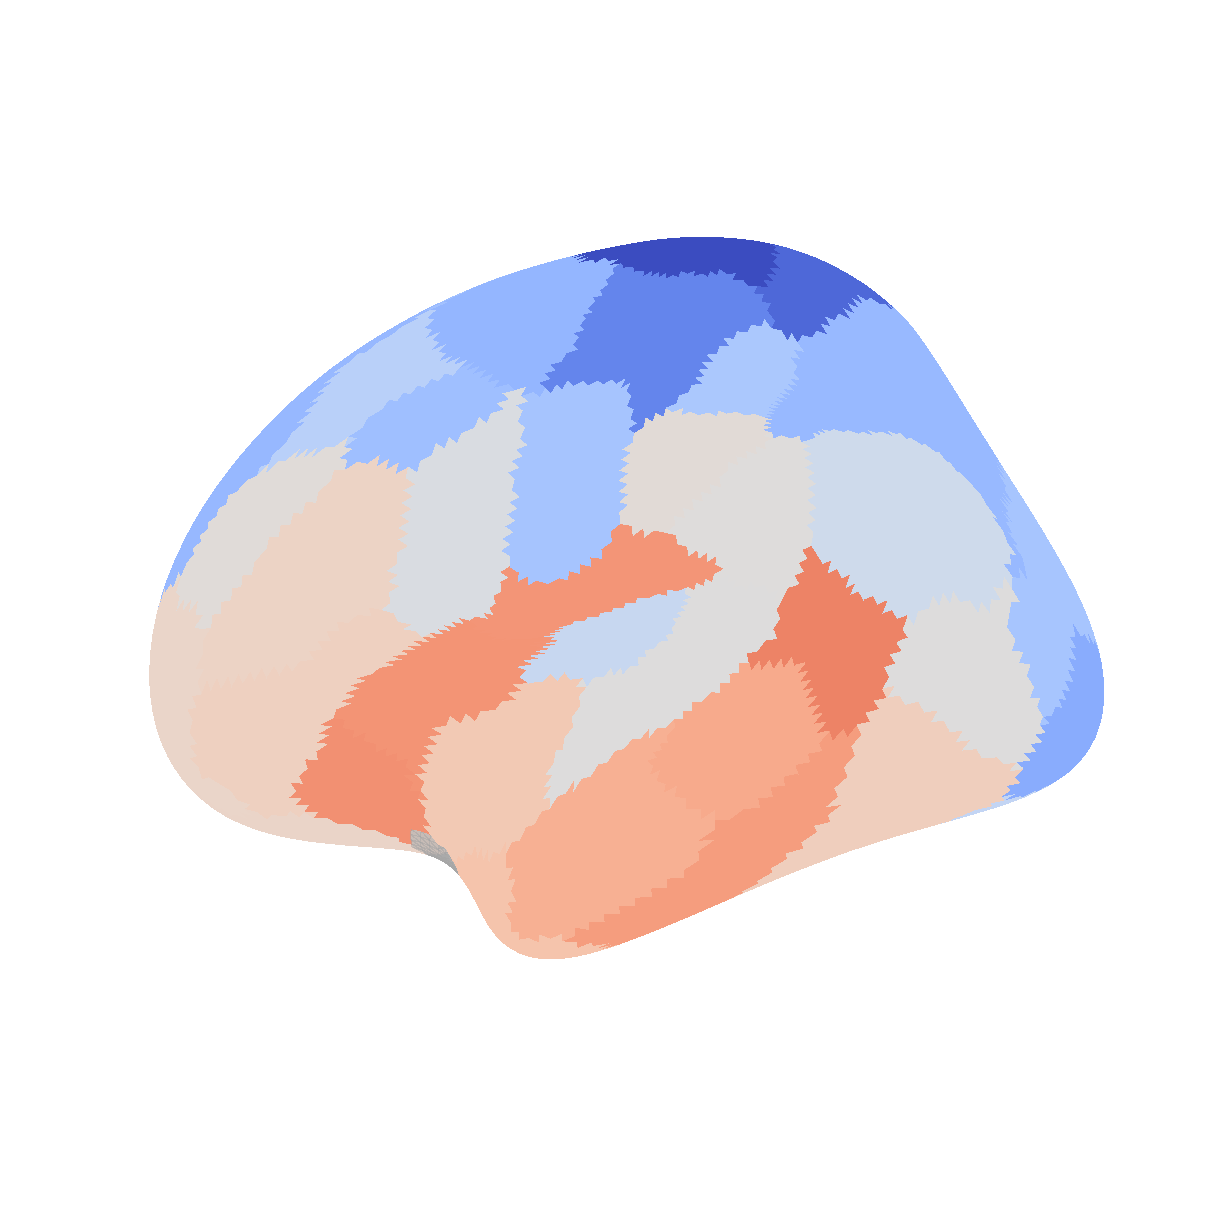

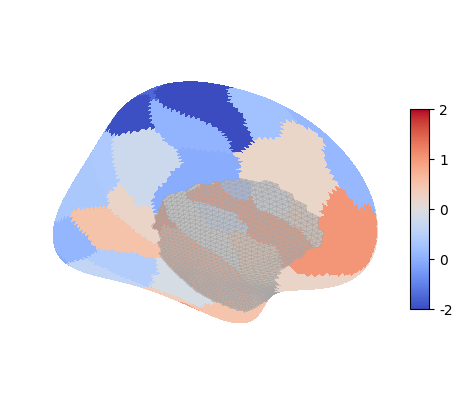

In [6]:
emp_atrophy = np.genfromtxt('/fs03/kg98/gchan/SIR_SCZ/SIR_utils/gen_null/spatial_null/voxelwise_lme/results/lme_beta_parc.csv', delimiter=',')
emp_atrophy = (emp_atrophy - np.mean(emp_atrophy)) / np.std(emp_atrophy)
emp_surf = emp_atrophy[atlas_surf.astype(int) - 1]
emp_surf[atlas_surf == 0] = np.nan

fig = plt.figure(figsize=(15, 12))
disp = nilearn.plotting.plot_surf_roi(fsaverage.infl_left, roi_map=emp_surf, hemi='left', view='lateral', cmap='coolwarm', figure=fig)
disp = nilearn.plotting.plot_surf_roi(fsaverage.infl_left, roi_map=emp_surf, hemi='left', view='medial', cmap='coolwarm', colorbar=True)


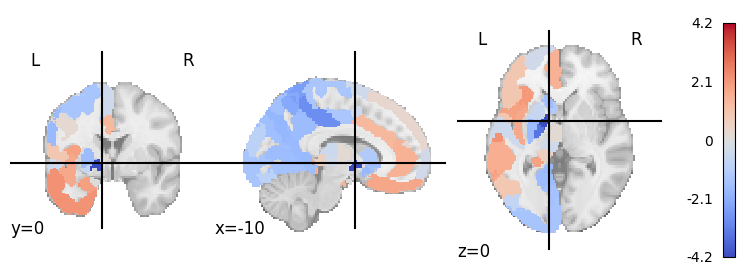

In [38]:
# project simulated atrophy onto the atlas
roi_mask = (atlas_data > 0) & (atlas_data < 66)
roi_indices = atlas_data[roi_mask].astype(int) - 1
sim_atrophy_data = np.zeros(atlas_data.shape)
sim_atrophy_data[roi_mask] = sim_atrophy[roi_indices].flatten()

sim_atrophy_header = atlas_img.header.copy()
sim_atrophy_affine = atlas_img.affine.copy()
sim_atrophy_img = nib.nifti1.Nifti1Image(sim_atrophy_data, sim_atrophy_affine, header=sim_atrophy_header)

# Volumetric plot of simulated atrophy
nilearn.plotting.plot_stat_map(sim_atrophy_img, cmap="coolwarm", cut_coords = (-10, 0, 0))

(<Figure size 400x900 with 3 Axes>, [<Axes3D: >, <Axes3D: >, <Axes: >])

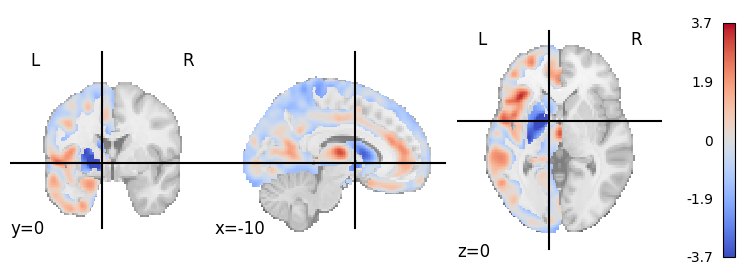

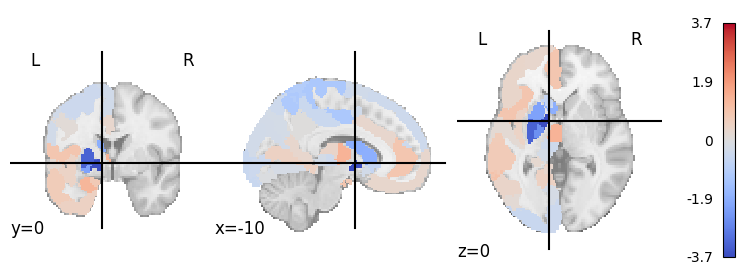

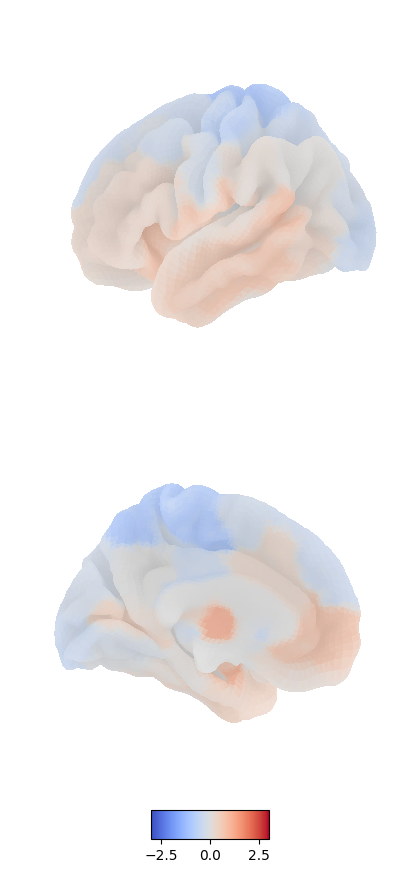

In [37]:
data_dir = ('/fs03/kg98/gchan/SIR_SCZ/SIR_utils/gen_null/spatial_null/voxelwise_lme/results/')
my_img = nib.load(data_dir + "lme_betas_2.nii.gz")
my_img_parc = nib.load(data_dir + "mean_lme_betas.nii.gz")

display = nilearn.plotting.plot_stat_map(my_img, cmap='coolwarm', cut_coords=[-10, 0, 0], vmax=3.7)
display = nilearn.plotting.plot_stat_map(my_img_parc, cmap='coolwarm', cut_coords=[-10, 0, 0], vmax=3.7)
nilearn.plotting.plot_img_on_surf(my_img_parc, hemispheres=['left'], bg_on_data=True, cmap='coolwarm', vmax=3)
